Libraries Imported Successfully
Prediction Box Shape: torch.Size([10, 4])
Target Box Shape: torch.Size([2, 4])

Matched Target Index:
[0, 1, 0, 1, 1, 0, 0, 0, 1, 0]

Loss Results
Box Regression Loss: 1.159
Classification Loss: 0.7619
Total Loss: 1.9209


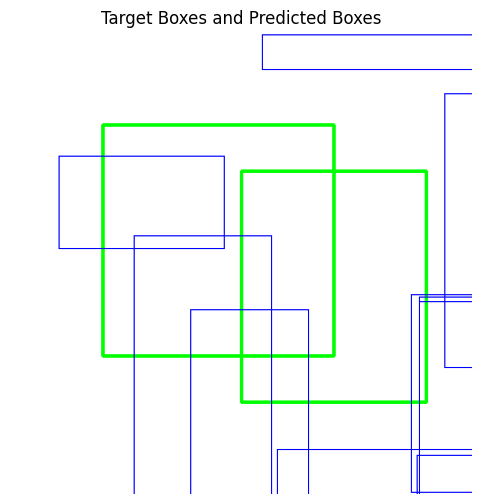


YOLO-Style Loss Experiment Completed


In [1]:
# ==========================================================
# TASK 9
# Anchor-Free YOLOv8-Style Loss
# ==========================================================

# ----------------------------------------------------------
# Step 1 - Import Libraries
# ----------------------------------------------------------

import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")


# ----------------------------------------------------------
# Step 2 - Create Sample Predictions
# ----------------------------------------------------------

torch.manual_seed(42)

# Number of predicted boxes
num_predictions = 10

# Each box = x1, y1, x2, y2
pred_boxes = torch.rand(
    num_predictions,
    4
)

# Make x2 and y2 greater than x1 and y1
pred_boxes[:, 2:] = (
    pred_boxes[:, :2]
    + pred_boxes[:, 2:]
)

# Prediction confidence
pred_scores = torch.rand(
    num_predictions,
    1
)

# Prediction class
pred_classes = torch.randint(
    0,
    2,
    (num_predictions,)
)

print("Prediction Box Shape:", pred_boxes.shape)


# ----------------------------------------------------------
# Step 3 - Create Target Boxes
# ----------------------------------------------------------

target_boxes = torch.tensor([
    [0.20, 0.20, 0.70, 0.70],
    [0.50, 0.30, 0.90, 0.80]
])

target_classes = torch.tensor([
    0,
    1
])

print("Target Box Shape:", target_boxes.shape)


# ----------------------------------------------------------
# Step 4 - Calculate IoU
# ----------------------------------------------------------

def calculate_iou(box1, box2):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )

    intersection_width = max(
        0,
        x2 - x1
    )

    intersection_height = max(
        0,
        y2 - y1
    )

    intersection = (
        intersection_width
        * intersection_height
    )

    area1 = (
        box1[2] - box1[0]
    ) * (
        box1[3] - box1[1]
    )

    area2 = (
        box2[2] - box2[0]
    ) * (
        box2[3] - box2[1]
    )

    union = area1 + area2 - intersection

    return intersection / (union + 1e-7)


# ----------------------------------------------------------
# Step 5 - Calculate CIoU
# ----------------------------------------------------------

def calculate_ciou(box1, box2):

    # Intersection over Union
    iou = calculate_iou(
        box1,
        box2
    )

    # Center points
    center1_x = (
        box1[0] + box1[2]
    ) / 2

    center1_y = (
        box1[1] + box1[3]
    ) / 2

    center2_x = (
        box2[0] + box2[2]
    ) / 2

    center2_y = (
        box2[1] + box2[3]
    ) / 2

    # Center distance
    center_distance = (
        (center1_x - center2_x) ** 2
        +
        (center1_y - center2_y) ** 2
    )

    # Enclosing box
    enclose_x1 = min(
        box1[0],
        box2[0]
    )

    enclose_y1 = min(
        box1[1],
        box2[1]
    )

    enclose_x2 = max(
        box1[2],
        box2[2]
    )

    enclose_y2 = max(
        box1[3],
        box2[3]
    )

    diagonal = (
        (enclose_x2 - enclose_x1) ** 2
        +
        (enclose_y2 - enclose_y1) ** 2
        + 1e-7
    )

    # Aspect ratios
    width1 = box1[2] - box1[0]
    height1 = box1[3] - box1[1]

    width2 = box2[2] - box2[0]
    height2 = box2[3] - box2[1]

    angle = (
        4 / (np.pi ** 2)
    ) * (
        torch.atan(
            width2 / (height2 + 1e-7)
        )
        -
        torch.atan(
            width1 / (height1 + 1e-7)
        )
    ) ** 2

    # CIoU penalty
    alpha = angle / (
        1 - iou + angle + 1e-7
    )

    ciou = (
        iou
        - center_distance / diagonal
        - alpha * angle
    )

    return ciou


# ----------------------------------------------------------
# Step 6 - Match Predictions with Targets
# ----------------------------------------------------------

def match_boxes(predictions, targets):

    matches = []

    for prediction in predictions:

        best_iou = 0
        best_target = 0

        for index, target in enumerate(targets):

            iou = calculate_iou(
                prediction,
                target
            )

            if iou > best_iou:

                best_iou = iou
                best_target = index

        matches.append(
            best_target
        )

    return matches


matched_targets = match_boxes(
    pred_boxes,
    target_boxes
)

print("\nMatched Target Index:")

print(matched_targets)


# ----------------------------------------------------------
# Step 7 - Calculate Box Regression Loss
# ----------------------------------------------------------

box_loss = 0

for i in range(num_predictions):

    target_index = matched_targets[i]

    ciou = calculate_ciou(
        pred_boxes[i],
        target_boxes[target_index]
    )

    box_loss += (
        1 - ciou
    )

box_loss = box_loss / num_predictions


# ----------------------------------------------------------
# Step 8 - Classification Loss
# ----------------------------------------------------------

classification_targets = []

for i in range(num_predictions):

    target_index = matched_targets[i]

    classification_targets.append(
        target_classes[target_index]
    )

classification_targets = torch.tensor(
    classification_targets
)

classification_targets = (
    classification_targets.float()
)

classification_loss_function = (
    nn.BCEWithLogitsLoss()
)

classification_loss = (
    classification_loss_function(
        pred_scores.squeeze(),
        classification_targets
    )
)


# ----------------------------------------------------------
# Step 9 - Total YOLO-Style Loss
# ----------------------------------------------------------

total_loss = (
    box_loss
    +
    classification_loss
)


print("\nLoss Results")

print(
    "Box Regression Loss:",
    round(box_loss.item(), 4)
)

print(
    "Classification Loss:",
    round(
        classification_loss.item(),
        4
    )
)

print(
    "Total Loss:",
    round(total_loss.item(), 4)
)


# ----------------------------------------------------------
# Step 10 - Visualize Bounding Boxes
# ----------------------------------------------------------

image = np.zeros(
    (400, 400, 3),
    dtype=np.uint8
)

image[:] = 255


# Draw target boxes
for box in target_boxes:

    x1 = int(box[0] * 400)
    y1 = int(box[1] * 400)

    x2 = int(box[2] * 400)
    y2 = int(box[3] * 400)

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )


# Draw predicted boxes
for box in pred_boxes:

    x1 = int(box[0] * 400)
    y1 = int(box[1] * 400)

    x2 = int(box[2] * 400)
    y2 = int(box[3] * 400)

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        1
    )


# ----------------------------------------------------------
# Step 11 - Display Image
# ----------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Target Boxes and Predicted Boxes"
)

plt.axis("off")

plt.show()


# ----------------------------------------------------------
# Step 12 - Experiment Completed
# ----------------------------------------------------------

print("\nYOLO-Style Loss Experiment Completed")